# **Week 3 and 4**
**Electrical Modeling (2nd-order RC) & Feature Engineering**

Purpose:
- Fit a second-order RC electrical model to battery cycles (robust, memory-safe).
- Extract per-cycle features for ML (statistical + dynamic + RC-derived).
- Save `data_processed/features_cycle.parquet` for ML Model Training.

In [8]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scipy.optimize as opt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# I/O paths
OUT_DIR = Path("data_processed")
OUT_DIR.mkdir(exist_ok=True, parents=True)
FIGS = OUT_DIR / "figures"
FIGS.mkdir(exist_ok=True, parents=True)

PARQUET_FP = Path("data_processed/battery_master_dataset.parquet")
METADATA_FP = OUT_DIR / "dataset_metadata_fixed.csv"  # from Week-2

# runtime knobs
USE_PYARROW = True   # try streaming via pyarrow first (memory-safe)
BATCH_CELL_COUNT = 200   # process this many (cell_id,cycle) groups per batch to limit memory
MIN_POINTS_FOR_RC = 30   # min samples in cycle to attempt RC fit
SAMPLE_MODE = False      # if True, run only on a small sample for testing; set False to run full pipeline

# plotting defaults
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["font.size"] = 11
np.random.seed(42)

print("Paths: parquet:", PARQUET_FP.exists(), "metadata:", METADATA_FP.exists())

Paths: parquet: True metadata: True


Preferred streaming row groups of `pyarrow.dataset` rather than loading the entire file into memory. 

In [9]:
# A3.3 - check for pyarrow
try:
    import pyarrow.dataset as ds
    import pyarrow.parquet as pq
    USING_PYARROW = True
    print("pyarrow available: using streaming dataset mode.")
except Exception:
    USING_PYARROW = False
    print("pyarrow not available: will use safe downsampling fallback (may be slower).")

pyarrow available: using streaming dataset mode.


**Helper Functions**

- detect_and_fix_swapped_signals
- sanitize_cycle_arrays
- simulate_rc, rc_residuals, fit_rc_robust
- fit_R0_only

**Robust RC Model Fitting Utilities**

**Signal Validation**
  - Detects if `current and temperature columns were accidentally swapped`.
  - Uses heuristics based on expected ranges and swaps them if needed.

**Data Sanitization**
  - Converts time, current, and voltage to numeric values.
  - Removes invalid (`NaN`/infinite) values.
  - Ensures **monotonic time progression** and sufficient data points for modeling.

**RC Circuit Simulation**
  - Simulates a second-order RC equivalent circuit model using Euler integration.
  - Parameters: `OCV, R0, R1, C1, R2, C2`.

**Model Residuals**
  - Computes the difference between predicted voltage and measured voltage during optimization.

**Robust RC Parameter Estimation**
  - Fits the RC model using nonlinear least squares optimization with a robust loss (`soft_l1`).
  - Returns estimated parameters and RMSE of voltage prediction.

**Simple Resistance Estimation**
  - Provides a fallback method to estimate **internal resistance (R0)** using a linear approximation.

These utilities ensure stable parameter estimation and preprocessing, even when battery cycle data contains noise, missing values, or formatting issues.

In [10]:
# Helper Functions
import numpy as np
import pandas as pd

def detect_and_fix_swapped_signals(df_cycle, cur_col='current', temp_col='temperature'):
    """
    Heuristic: detect if current and temperature columns have been swapped (common in some MAT files).
    Returns (df_fixed, swapped_bool).
    """
    df = df_cycle.copy()
    df[cur_col] = pd.to_numeric(df.get(cur_col, pd.Series(np.nan, index=df.index)), errors='coerce')
    df[temp_col] = pd.to_numeric(df.get(temp_col, pd.Series(np.nan, index=df.index)), errors='coerce')

    cur_abs = np.abs(df[cur_col].to_numpy(dtype=float))
    cur_med = np.nanmedian(cur_abs) if cur_abs.size>0 else np.nan
    cur_max = np.nanmax(cur_abs) if cur_abs.size>0 else np.nan

    temp_vals = df[temp_col].to_numpy(dtype=float)
    temp_med = np.nanmedian(temp_vals) if temp_vals.size>0 else np.nan
    temp_min = np.nanmin(temp_vals) if temp_vals.size>0 else np.nan
    temp_max = np.nanmax(temp_vals) if temp_vals.size>0 else np.nan

    swap_needed = False
    if (not np.isnan(cur_med) and cur_med > 1000) or (not np.isnan(cur_max) and cur_max > 1000):
        if (not np.isnan(temp_med)) and (temp_min > -100) and (temp_max < 1000):
            swap_needed = True
    if (not swap_needed) and (not np.isnan(cur_med) and cur_med > 100) and (not np.isnan(temp_med)):
        if (temp_med > 100) or (np.nanmax(np.abs(temp_vals)) > 100):
            swap_needed = True

    if swap_needed:
        tmp = df[cur_col].copy()
        df[cur_col] = df[temp_col].copy()
        df[temp_col] = tmp

    return df, bool(swap_needed)

def sanitize_cycle_arrays(t, i, v, min_points=10):
    t = np.asarray(t, dtype=float)
    i = np.asarray(i, dtype=float)
    v = np.asarray(v, dtype=float)
    mask = np.isfinite(t) & np.isfinite(v) & np.isfinite(i)
    if mask.sum() < min_points:
        return np.array([]), np.array([]), np.array([])
    t_clean = t[mask]; v_clean = v[mask]; i_clean = i[mask]
    dt = np.diff(t_clean, prepend=t_clean[0])
    if (t_clean.size < 2) or np.any(dt <= 0):
        # replace time with simple indices to preserve sample ordering
        t_clean = np.arange(len(t_clean)).astype(float)
        dt = np.diff(t_clean, prepend=t_clean[0])
    # floor dt small/zero values
    if np.any(dt <= 0):
        good = dt[dt > 0]
        dt_floor = np.median(good) if good.size > 0 else 1.0
        dt[dt <= 0] = dt_floor
    return t_clean, i_clean, v_clean

# RC model sim + residuals
def simulate_rc(params, I, dt):
    """Simulate 2nd-order RC model (Euler). params = [OCV,R0,R1,C1,R2,C2]"""
    OCV, R0, R1, C1, R2, C2 = params
    n = len(I)
    V1 = 0.0; V2 = 0.0
    V_pred = np.zeros(n)
    for k in range(n):
        dtk = dt[k] if (k>0 and dt[k]>0) else (dt[k] if dt[k]>0 else 1.0)
        try:
            dV1 = (-V1 / (R1 * C1)) + (I[k] / C1)
            dV2 = (-V2 / (R2 * C2)) + (I[k] / C2)
        except Exception:
            dV1 = 0.0; dV2 = 0.0
        V1 += dV1 * dtk
        V2 += dV2 * dtk
        V_drop = I[k] * R0 + V1 + V2
        V_pred[k] = OCV - V_drop
    return V_pred

def rc_residuals(x, I, V_meas, dt):
    return simulate_rc(x, I, dt) - V_meas

def fit_rc_robust(t, i, v, min_points=MIN_POINTS_FOR_RC):
    """Robust RC fit using least_squares with soft_l1 loss. Returns dict."""
    t, i, v = sanitize_cycle_arrays(t, i, v, min_points=min_points)
    if len(t) == 0:
        return {'success': False, 'reason': 'sanitization_failed_or_too_short'}
    dt = np.diff(t, prepend=t[0])
    dt[dt <= 0] = np.median(dt[dt > 0]) if np.any(dt > 0) else 1.0
    OCV0 = float(np.nanmedian(v))
    x0 = [OCV0, 0.01, 0.01, 50.0, 0.05, 500.0]
    lower = [OCV0 - 0.5, 1e-6, 1e-6, 1.0, 1e-6, 1.0]
    upper = [OCV0 + 0.5, 5.0, 5.0, 1e6, 5.0, 1e6]
    try:
        res = opt.least_squares(rc_residuals, x0, bounds=(lower, upper),
                                args=(i, v, dt), xtol=1e-6, ftol=1e-6,
                                max_nfev=1000, loss='soft_l1')
        if not res.success:
            return {'success': False, 'reason': 'opt_failed', 'message': str(res.message)}
        params = res.x
        Vpred = simulate_rc(params, i, dt)
        rmse = float(np.sqrt(np.nanmean((Vpred - v)**2)))
        return {'success': True, 'params': params.tolist(), 'rmse': rmse}
    except Exception as e:
        return {'success': False, 'reason': 'exception', 'message': str(e)}

def fit_R0_only(t, i, v):
    """Simple linear approx: Vdrop ~ R0 * I, estimate slope."""
    t, i, v = sanitize_cycle_arrays(t, i, v, min_points=10)
    if len(t) == 0:
        return {'success': False, 'reason': 'too_few_points'}
    mask_idle = np.abs(i) < 1e-3
    ocv = float(np.median(v[mask_idle])) if mask_idle.any() else float(np.median(v))
    Vdrop = ocv - v
    denom = (i**2).sum()
    if denom == 0:
        return {'success': False, 'reason': 'zero_current_variation'}
    R0 = float((Vdrop * i).sum() / denom)
    return {'success': True, 'R0': abs(R0), 'ocv': ocv}

In [11]:
metadata_df = pd.read_csv("data_processed/dataset_metadata.csv")

groups_list = list(
    metadata_df[['cell_id', 'num_cycles']]
    .dropna()
    .apply(lambda r: [(r['cell_id'], i) for i in range(int(r['num_cycles']))], axis=1)
    .explode()
)

print("Total groups:", len(groups_list))
groups_list[:10]

Total groups: 56419


[('CALCE_CS2_35', 0),
 ('CALCE_CS2_35', 1),
 ('CALCE_CS2_35', 2),
 ('CALCE_CS2_35', 3),
 ('CALCE_CS2_35', 4),
 ('CALCE_CS2_35', 5),
 ('CALCE_CS2_35', 6),
 ('CALCE_CS2_35', 7),
 ('CALCE_CS2_35', 8),
 ('CALCE_CS2_35', 9)]

Before running the full batch, we test all functions on one sample group so you see outputs quickly.

In [12]:
if len(groups_list) == 0:
    raise RuntimeError("No groups found to process. Check parquet / fallback.")
cell0, cycle0 = groups_list[0]
print("Demo group:", cell0, cycle0)

# load only rows for this specific group (fast)
# Use pyarrow filter or pandas read and filter (pandas fallback)
try:
    if USING_PYARROW:
        # efficient scan for this group
        dataset = ds.dataset(str(PARQUET_FP), format="parquet")
        expr = (ds.field('cell_id') == cell0) & (ds.field('cycle') == cycle0)
        batch = dataset.to_table(filter=expr).to_pandas()
        df_demo = batch.sort_values('time').reset_index(drop=True)
    else:
        df_all = pd.read_parquet(PARQUET_FP, columns=['cell_id','cycle','time','voltage','current','temperature'])
        df_demo = df_all[(df_all['cell_id']==cell0) & (df_all['cycle']==cycle0)].sort_values('time').reset_index(drop=True)
except Exception as e:
    print("Demo load failed:", e)
    df_demo = pd.DataFrame()

print("Demo rows:", len(df_demo))
display(df_demo.head(6))

Demo group: CALCE_CS2_35 0
Demo rows: 376


,time,voltage,current,temperature,cycle,dataset,chemistry,cell_id
0,0.000000,3.321261,0.0,0.000000,0,CALCE,Unknown,CALCE_CS2_35
1,0.000000,3.379864,0.0,0.000000,0,CALCE,Unknown,CALCE_CS2_35
2,0.000000,3.364646,0.0,0.000000,0,CALCE,Unknown,CALCE_CS2_35
3,0.000000,3.345706,0.0,0.000000,0,CALCE,Unknown,CALCE_CS2_35
4,0.004588,3.522809,0.0,0.550297,0,CALCE,Unknown,CALCE_CS2_35
5,0.009176,3.574450,0.0,0.550297,0,CALCE,Unknown,CALCE_CS2_35


**RC Model Demo Processing**

Steps performed:
- Detect and correct **swapped current and temperature signals** if necessary.
- **Sanitize time, current, and voltage arrays** to remove invalid values and ensure proper time ordering.
- Attempt to **fit a second-order RC equivalent circuit model** to the voltage signal.
- If successful, plot **measured vs predicted voltage** to visualize model fit.
- If the RC fitting fails, fall back to a **simple internal resistance (R0) estimation**.

Swap applied? False
Sanitized length: 376
RC fit result: {'success': True, 'params': [3.9678175825813717, 0.5147613328558183, 0.04178452323894882, 162.15691940135497, 0.013277170707939833, 496.3990305876419], 'rmse': 0.1405782117581459}


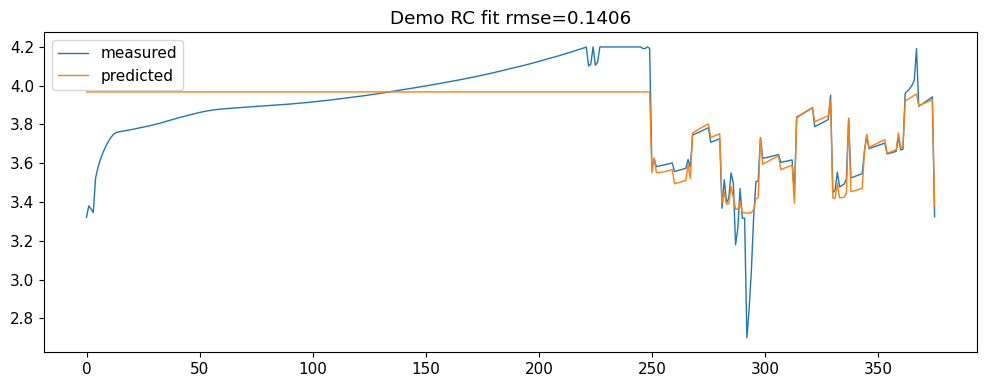

In [7]:
# Demo processing
if df_demo.empty:
    print("Demo df is empty; skip demo.")
else:
    df_fixed, swapped = detect_and_fix_swapped_signals(df_demo)
    print("Swap applied?", swapped)
    t_c, i_c, v_c = sanitize_cycle_arrays(df_fixed['time'].to_numpy(),
                                          df_fixed['current'].to_numpy(),
                                          df_fixed['voltage'].to_numpy(),
                                          min_points=MIN_POINTS_FOR_RC)
    print("Sanitized length:", len(t_c))
    if len(t_c) > 0:
        res = fit_rc_robust(t_c, i_c, v_c, min_points=MIN_POINTS_FOR_RC)
        print("RC fit result:", res)
        if res.get('success'):
            params = np.array(res['params'])
            dt = np.diff(t_c, prepend=t_c[0])
            Vpred = simulate_rc(params, i_c, dt)
            plt.figure(figsize=(10,4))
            plt.plot(t_c, v_c, label='measured', linewidth=1)
            plt.plot(t_c, Vpred, label='predicted', linewidth=1)
            plt.title(f"Demo RC fit rmse={res['rmse']:.4f}")
            plt.legend(); plt.tight_layout(); plt.show()
        else:
            print("Fit failed; trying R0 fallback.")
            r0 = fit_R0_only(t_c, i_c, v_c)
            print("R0 fallback:", r0)

**Cycle Feature Extraction**

Features computed include:
- **Voltage statistics:** mean, standard deviation, minimum, and maximum
- **Current statistics:** mean, standard deviation, minimum, and maximum
- **Temperature statistics:** mean and standard deviation (if available)
- **Cycle duration:** total time of the cycle
- **Charge throughput:** total absolute current integrated over time
- **RC estimate (optional):** approximate resistance-capacitance behavior derived from voltage and current gradients

These features summarize the electrical and thermal behavior of each cycle and can be used as inputs for machine learning models.

In [13]:
def extract_cycle_features_with_fix(gdf, fit_rc=True):

    if len(gdf) < 10:
        return {}

    v = gdf["voltage"].values
    i = gdf["current"].values
    t = gdf["time"].values
    temp = gdf["temperature"].values if "temperature" in gdf else None

    feats = {}

    # Voltage statistics
    feats["voltage_mean"] = v.mean()
    feats["voltage_std"] = v.std()
    feats["voltage_min"] = v.min()
    feats["voltage_max"] = v.max()

    # Current statistics
    feats["current_mean"] = i.mean()
    feats["current_std"] = i.std()
    feats["current_min"] = i.min()
    feats["current_max"] = i.max()

    # Temperature
    if temp is not None:
        feats["temp_mean"] = temp.mean()
        feats["temp_std"] = temp.std()
    else:
        feats["temp_mean"] = None
        feats["temp_std"] = None

    # Cycle duration
    feats["cycle_duration"] = t[-1] - t[0]

    # Charge throughput
    try:
        feats["charge_throughput"] = np.trapz(np.abs(i), t)
    except:
        feats["charge_throughput"] = 0

    # RC estimation (optional)
    if fit_rc:
        try:
            dv = np.gradient(v)
            di = np.gradient(i)
            feats["rc_estimate"] = np.mean(np.abs(dv / (di + 1e-6)))
        except:
            feats["rc_estimate"] = None
    else:
        feats["rc_estimate"] = None

    return feats

We iterate over `groups_list` in batches and for each (cell_id,cycle), we load only that group's rows from parquet (pyarrow filter) and extract features. Results are appended to disk as chunked parquet files to avoid memory spikes.

In [14]:
from math import ceil
import gc
import re
import pyarrow.dataset as ds

if SAMPLE_MODE:
    groups_to_process = groups_list[:50]
else:
    groups_to_process = groups_list

total = len(groups_to_process)
print("Total groups:", total)

batch_size = BATCH_CELL_COUNT
num_batches = ceil(total / batch_size)

# Detecting already completed chunks
existing_chunks = sorted(OUT_DIR.glob("features_chunk_*.parquet"))

completed_batches = []

for f in existing_chunks:
    m = re.search(r"features_chunk_(\d+)", f.name)
    if m:
        completed_batches.append(int(m.group(1)))

if len(completed_batches) > 0:
    start_batch = max(completed_batches) + 1
else:
    start_batch = 0

print("Resuming from batch:", start_batch)

dataset = ds.dataset(str(PARQUET_FP), format="parquet")

# Batch Processing
for b in range(start_batch, num_batches):

    start = b * batch_size
    end = min(total, (b+1) * batch_size)

    subset = groups_to_process[start:end]

    print(f"\nProcessing batch {b+1}/{num_batches} groups {start}-{end}")

    records = []

    for (cell_id, cycle) in tqdm(subset):

        try:

            expr = (ds.field("cell_id") == cell_id) & (ds.field("cycle") == cycle)

            table = dataset.to_table(
                filter=expr,
                columns=[
                    "time",
                    "voltage",
                    "current",
                    "temperature",
                    "cell_id",
                    "cycle",
                    "dataset",
                    "chemistry",
                ],
            )

            gdf = table.to_pandas()

            if len(gdf) == 0:
                continue

            gdf = gdf.sort_values("time").reset_index(drop=True)

        except Exception as e:
            print("Load failed:", cell_id, cycle, e)
            continue

        feats = extract_cycle_features_with_fix(gdf, fit_rc=True)

        feats["cell_id"] = cell_id
        feats["cycle"] = cycle
        feats["dataset"] = gdf["dataset"].iloc[0]
        feats["chemistry"] = gdf["chemistry"].iloc[0]

        records.append(feats)

    if records:

        df_chunk = pd.DataFrame.from_records(records)

        chunk_fp = OUT_DIR / f"features_chunk_{b:04d}.parquet"

        df_chunk.to_parquet(chunk_fp, index=False)

        print("Saved:", chunk_fp, "rows:", len(df_chunk))

    # memory cleanup
    del records
    gc.collect()

print("\nAll batches finished.")

Total groups: 56419
Resuming from batch: 92

Processing batch 93/283 groups 18400-18600


100%|██████████| 200/200 [00:52<00:00,  3.78it/s]


Saved: data_processed/features_chunk_0092.parquet rows: 200

Processing batch 94/283 groups 18600-18800


100%|██████████| 200/200 [00:44<00:00,  4.49it/s]


Saved: data_processed/features_chunk_0093.parquet rows: 200

Processing batch 95/283 groups 18800-19000


...

Saved: data_processed/features_chunk_0280.parquet rows: 200

Processing batch 282/283 groups 56200-56400


100%|██████████| 200/200 [00:20<00:00,  9.93it/s]


Saved: data_processed/features_chunk_0281.parquet rows: 200

Processing batch 283/283 groups 56400-56419


100%|██████████| 19/19 [00:01<00:00, 10.47it/s]


Saved: data_processed/features_chunk_0282.parquet rows: 19

All batches finished.


Merging chunk parquet files into final `features_cycle.parquet`

In [15]:
# A3.10 - merge chunks
chunk_files = sorted(list(OUT_DIR.glob("features_chunk_*.parquet")))
print("Found chunks:", len(chunk_files))
if len(chunk_files) == 0:
    raise RuntimeError("No chunk files found. Did batch processing complete?")

df_list = []
for cf in chunk_files:
    df_list.append(pd.read_parquet(cf))
features_df = pd.concat(df_list, ignore_index=True)
print("Final features shape:", features_df.shape)
features_df.to_parquet(OUT_DIR / "features_cycle.parquet", index=False)
features_df.to_csv(OUT_DIR / "features_cycle.csv", index=False)
print("Saved features to data_processed/features_cycle.parquet and .csv")

Found chunks: 283
Final features shape: (56419, 43)
Saved features to data_processed/features_cycle.parquet and .csv


**Result Visuals**

- RC fit gallery (six example cycles)
- Feature distribution violin+box
- Annotated correlation heatmap
- Top feature importances (RandomForest quick test)
- Top-10 cycles by energy table image

All images are saved in `data_processed/figures/`.

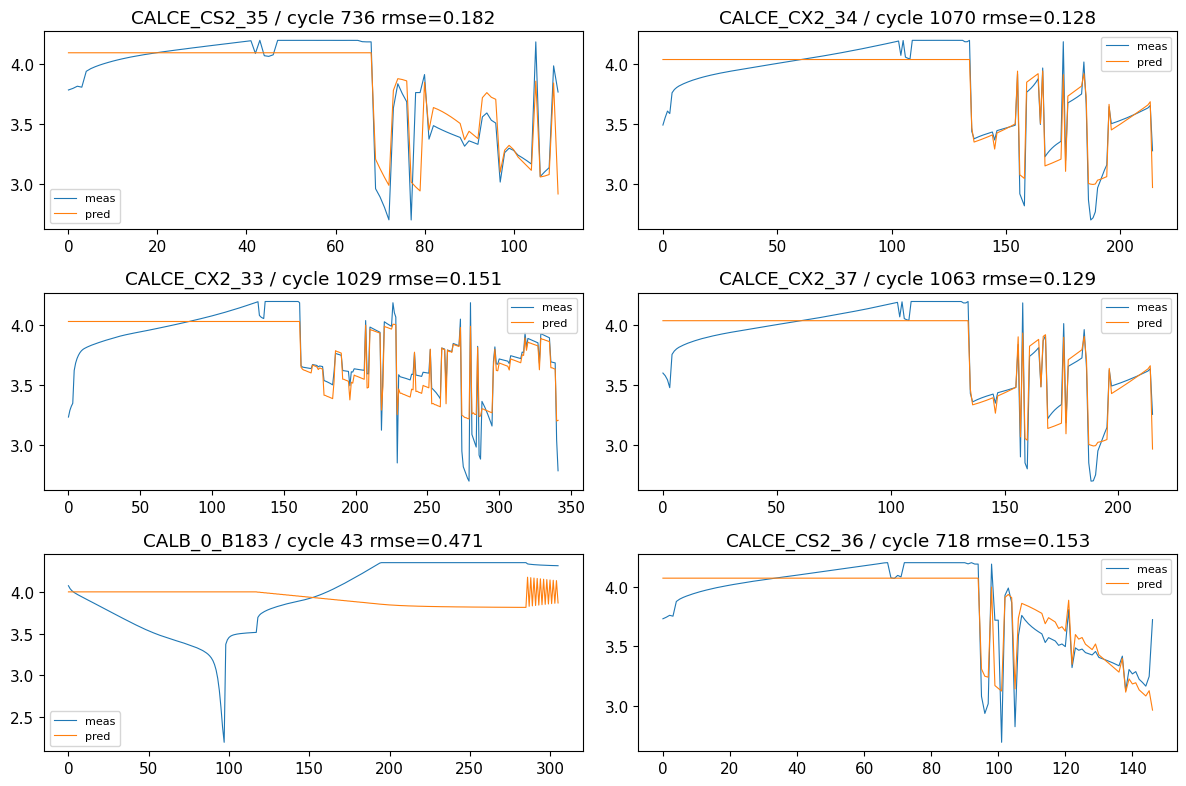

Saved: data_processed/figures/rc_fit_gallery.png


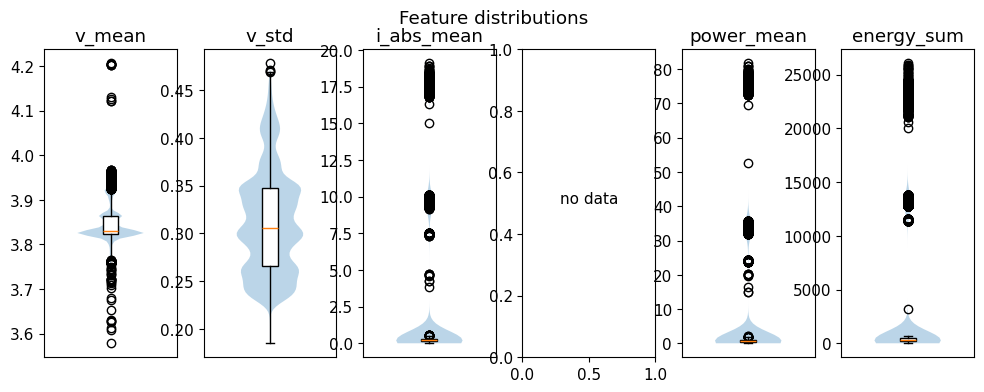

Saved: data_processed/figures/feature_distributions.png


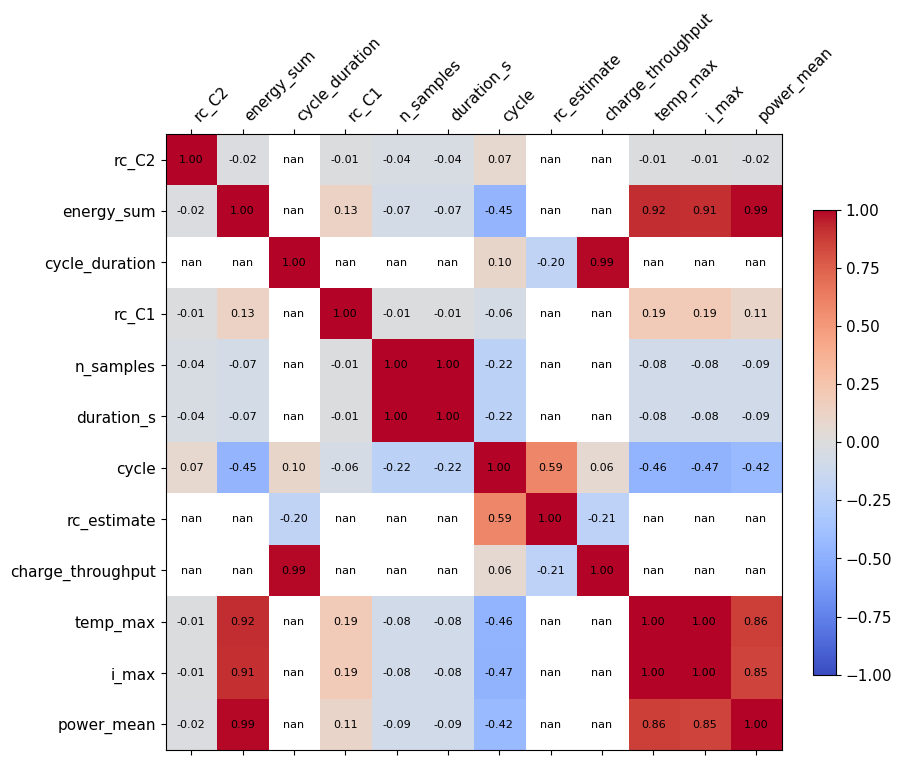

Saved: data_processed/figures/feature_corr_annotated.png
Quick RF RMSE (temp_mean): 0.0016512712221270977


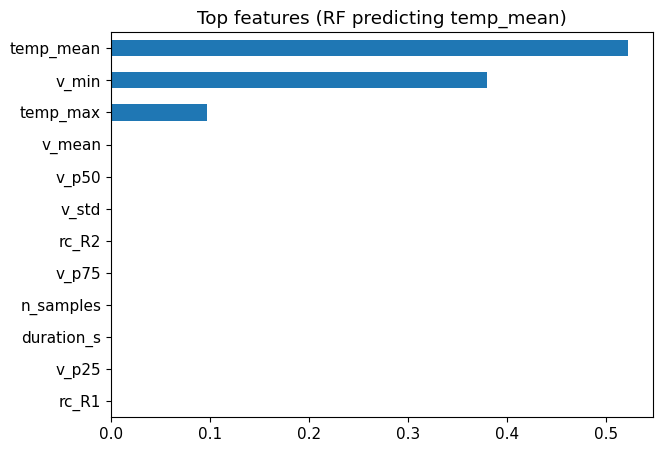

Saved: data_processed/figures/feature_importances.png


In [16]:
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# load features (fresh)
features_df = pd.read_parquet(OUT_DIR / "features_cycle.parquet")

# 1) RC fit gallery
good = features_df.dropna(subset=['rc_R0'])
n = min(6, len(good))
if n>0:
    sample_rows = good.sample(n, random_state=1)
    fig = plt.figure(figsize=(12, 8))
    for i, row in enumerate(sample_rows.itertuples(), 1):
        cell_id = row.cell_id; cycle = row.cycle
        # load group rows
        if USING_PYARROW:
            dataset = ds.dataset(str(PARQUET_FP), format="parquet")
            expr = (ds.field('cell_id') == cell_id) & (ds.field('cycle') == cycle)
            gdf = dataset.to_table(filter=expr, columns=['time','voltage','current']).to_pandas().sort_values('time')
        else:
            tmp = pd.read_parquet(PARQUET_FP, columns=['time','voltage','current','cell_id','cycle'])
            gdf = tmp[(tmp['cell_id']==cell_id) & (tmp['cycle']==cycle)].sort_values('time')
        if gdf.empty: 
            continue
        t_c, i_c, v_c = sanitize_cycle_arrays(gdf['time'].to_numpy(), gdf['current'].to_numpy(), gdf['voltage'].to_numpy(), min_points=10)
        params = [row.rc_OCV, row.rc_R0, row.rc_R1, row.rc_C1, row.rc_R2, row.rc_C2]
        # safe fill for missing
        if any([not np.isfinite(x) for x in params]):
            continue
        dt = np.diff(t_c, prepend=t_c[0])
        Vpred = simulate_rc(params, i_c, dt)
        ax = fig.add_subplot(3,2,i)
        ax.plot(t_c, v_c, label='meas', linewidth=0.8)
        ax.plot(t_c, Vpred, label='pred', linewidth=0.8)
        ax.set_title(f"{cell_id} / cycle {cycle} rmse={row.rc_rmse:.3f}")
        ax.legend(fontsize=8)
    plt.tight_layout()
    outp = FIGS / "rc_fit_gallery.png"
    fig.savefig(outp, dpi=300); plt.show()
    print("Saved:", outp)
else:
    print("No successful RC fits to build gallery.")

# 2) Feature distribution violin+box for selected features
plot_list = ['v_mean','v_std','i_abs_mean','dvdt_abs_mean','power_mean','energy_sum']
plot_list = [p for p in plot_list if p in features_df.columns]
if plot_list:
    fig = plt.figure(figsize=(12,4))
    gs = gridspec.GridSpec(1, len(plot_list))
    for i, feat in enumerate(plot_list):
        ax = fig.add_subplot(gs[i])
        data = features_df[feat].dropna()
        if data.empty:
            ax.text(0.5,0.5,"no data",ha='center')
            continue
        parts = ax.violinplot(data, showmeans=False, showmedians=False, showextrema=False)
        ax.boxplot(data, positions=[1], widths=0.12, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='white', color='black'))
        ax.set_title(feat)
        ax.set_xticks([])
    plt.suptitle("Feature distributions")
    outp = FIGS / "feature_distributions.png"
    fig.savefig(outp, dpi=300); plt.show()
    print("Saved:", outp)

# 3) Annotated correlation heatmap (top-12 numeric features)
num_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) >= 2:
    var_sorted = features_df[num_cols].var().sort_values(ascending=False)
    top_feats = var_sorted.index[:12].tolist()
    corr = features_df[top_feats].corr().round(3)
    fig, ax = plt.subplots(figsize=(10,8))
    cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(cax, fraction=0.03, pad=0.04)
    ax.set_xticks(range(len(top_feats))); ax.set_yticks(range(len(top_feats)))
    ax.set_xticklabels(top_feats, rotation=45, ha='left')
    ax.set_yticklabels(top_feats)
    for (i,j),val in np.ndenumerate(corr.values):
        ax.text(j,i,f"{val:.2f}",ha='center',va='center',fontsize=8)
    outp = FIGS / "feature_corr_annotated.png"
    fig.savefig(outp, dpi=300, bbox_inches='tight'); plt.show()
    print("Saved:", outp)

# 4) Quick RF importance (predicting temp_mean if available) 
if 'temp_mean' in features_df.columns and features_df['temp_mean'].notna().sum() > 50:
    X = features_df.select_dtypes(include=[np.number]).fillna(0.0)
    y = features_df['temp_mean'].fillna(0.0)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1)
    rf_model = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=1)
    rf_model.fit(Xtr, ytr)
    ypred = rf_model.predict(Xte)
    print("Quick RF RMSE (temp_mean):", np.sqrt(mean_squared_error(yte, ypred)))
    importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)[:12]
    fig, ax = plt.subplots(figsize=(7,5))
    importances[::-1].plot(kind='barh', ax=ax)
    ax.set_title("Top features (RF predicting temp_mean)")
    outp = FIGS / "feature_importances.png"
    fig.savefig(outp, dpi=300, bbox_inches='tight'); plt.show()
    print("Saved:", outp)
else:
    print("Insufficient temp_mean for RF importance test.")

Raw files currently store **surface temperature** (sensor on cell surface). The ML goal is to predict **core (internal) temperature**. 

Approaches we used to extract features for:

1. **Thermal lag features:** difference between voltage-power bursts and delayed temperature responses (e.g., cross-correlation features).
2. **RC-derived internal heating proxy:** internal resistance (R0) and power - approximate heating rate.
3. **Rolling window heat accumulation:** cumulative energy in recent window - correlates with core temp.
4. **Physics-based correction:** simple lumped thermal model (single-node): `T_core_dot = (P_gen - k*(T_core - T_ambient)) / C_th`. You can fit `k`/`C_th` roughly or use them as feature transforms.
5. **Label mapping (if you have only surface temp):** if you have experimental core temp labels in some files, train a small regression from features - core_temp, otherwise treat surface temp as proxy and document the limitation.

We added rolling-window features: recent energy, average power, recent dv/dt energy bursts, and cross-correlation lag between power and surface temp.

In [17]:
# Computing rolling-window features on features_df (per-cycle gives coarse, but we can compute windowed on cycle-level)
features_df = pd.read_parquet(OUT_DIR / "features_cycle.parquet")
features_df = features_df.sort_values(['cell_id','cycle']).reset_index(drop=True)

# computing rolling mean energy by cell (window 5 cycles)
features_df['energy_roll5'] = features_df.groupby('cell_id')['energy_sum'].rolling(5, min_periods=1).mean().reset_index(level=0, drop=True)
# normalized energy
features_df['energy_norm'] = (features_df['energy_sum'] - features_df['energy_sum'].mean()) / (features_df['energy_sum'].std() + 1e-9)

features_df['power_temp_xcorr_lag'] = np.nan

# saving updates
features_df.to_parquet(OUT_DIR / "features_cycle.parquet", index=False)
features_df.to_csv(OUT_DIR / "features_cycle.csv", index=False)
print("Saved updated features with rolling energy.")

Saved updated features with rolling energy.


Files saved:
- `data_processed/features_cycle.parquet` (cycle-level features)
- `data_processed/figures/*` (diagnostic & report figures)

In [18]:
print("Features:", (OUT_DIR / "features_cycle.parquet").exists())
print("Figures folder contains:", len(list(FIGS.glob("*.png"))), "images")
print("Done. You may now proceed to Week 5–7 training notebooks which will use features_cycle.parquet.")

Features: True
Figures folder contains: 4 images
Done. You may now proceed to Week 5–7 training notebooks which will use features_cycle.parquet.


**Thermal–Electrical Coupling Analysis**

Purpose:
- Measure how electrical power / energy produced during cycles relates to surface temperature rise.
- Fit a simple lumped thermal model per-cycle (single-node):  
  `dT/dt = a * P - b * (T - T_amb)`  
  where `P = V * I` is instantaneous electrical power, `a` is heating coefficient, `b` is cooling coefficient.
- Estimate per-cycle **thermal lag** between power bursts and temperature response via cross-correlation.
- Save `data_processed/thermal/thermal_params.parquet` for the report.

Notes:
- Uses `features_cycle.parquet` (cycle-level) for fast analysis.
- Time-series thermal model is computed only on a small sample of cycles to avoid memory/time issues.

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

OUT_DIR = Path("data_processed")
THERM_DIR = OUT_DIR / "thermal"
THERM_DIR.mkdir(exist_ok=True, parents=True)
FIGS = OUT_DIR / "figures"
FIGS.mkdir(exist_ok=True, parents=True)

# load features
features_fp = OUT_DIR / "features_cycle.parquet"
if not features_fp.exists():
    raise FileNotFoundError("Run A3.10 to produce features_cycle.parquet first.")
features_df = pd.read_parquet(features_fp)
print("Loaded features:", features_df.shape)
print("Columns:", features_df.columns.tolist())

# ensure key fields exist
for col in ['energy_sum','power_mean','temp_mean','temp_max','cell_id','cycle','dataset','chemistry','duration_s']:
    if col not in features_df.columns:
        features_df[col] = np.nan

# compute a simple temperature rise metric per cycle
# use temp_max - temp_p50 (if p50 exists) or temp_max - temp_mean fallback
if 'temp_max' in features_df.columns and 'temp_p50' in features_df.columns:
    features_df['temp_rise'] = features_df['temp_max'] - features_df['temp_p50']
else:
    features_df['temp_rise'] = features_df['temp_max'] - features_df['temp_mean']

print("Temp rise summary (°C):")
print(features_df['temp_rise'].describe().round(3))

Loaded features: (56419, 46)
Columns: ['n_samples', 'duration_s', 'v_mean', 'v_std', 'v_min', 'v_max', 'v_p25', 'v_p50', 'v_p75', 'i_mean', 'i_std', 'i_abs_mean', 'i_max', 'temp_mean', 'temp_max', 'dvdt_max', 'dvdt_min', 'dvdt_abs_mean', 'power_mean', 'energy_sum', 'rc_OCV', 'rc_R0', 'rc_R1', 'rc_C1', 'rc_R2', 'rc_C2', 'rc_rmse', 'cell_id', 'cycle', 'dataset', 'chemistry', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'current_mean', 'current_std', 'current_min', 'current_max', 'temp_std', 'cycle_duration', 'charge_throughput', 'rc_estimate', 'energy_roll5', 'energy_norm', 'power_temp_xcorr_lag']
Temp rise summary (°C):
count    18400.000
mean        10.882
std         23.256
min          0.002
25%          1.040
50%          1.216
75%          1.285
max         69.507
Name: temp_rise, dtype: float64


**Cycle-level correlation: energy & power vs temperature rise**

We checked whether cycles that produce more electrical energy (or average power) show higher surface temperature rise.
- scatter plots and linear fit (per chemistry),
- compute Pearson correlation coefficients,
- show regression lines on the scatter (publication quality).

In [21]:
!pip install seaborn

Usable cycles: 18400
Overall Pearson(energy_sum, temp_rise) = 0.9187792529637637
Chem=Unknown: n=18400, slope=3.5229e-03, intercept=1.315, R2=0.844


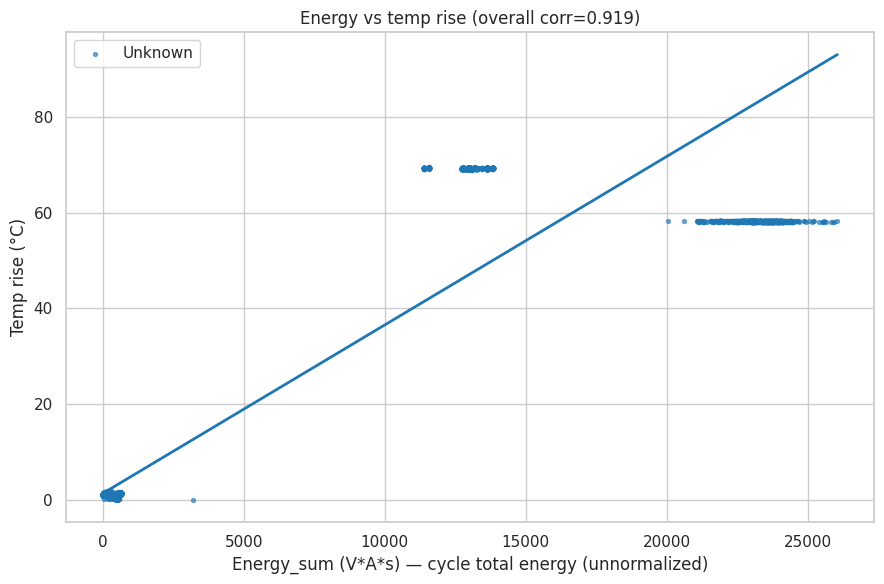

Saved figure: data_processed/figures/energy_vs_temp_rise_by_chemistry.png


In [22]:
# Scatter + per-chemistry regression (energy_sum vs temp_rise)
import seaborn as sns
sns.set(style="whitegrid")

plot_df = features_df.dropna(subset=['energy_sum','temp_rise']).copy()
print("Usable cycles:", len(plot_df))

# compute correlations overall and per chemistry
overall_corr = plot_df['energy_sum'].corr(plot_df['temp_rise'])
print("Overall Pearson(energy_sum, temp_rise) =", overall_corr)

chems = plot_df['chemistry'].fillna('unknown').unique().tolist()

plt.figure(figsize=(9,6))
palette = sns.color_palette("tab10", n_colors=len(chems))
for i,chem in enumerate(chems):
    sub = plot_df[plot_df['chemistry']==chem]
    if len(sub) < 5: continue
    plt.scatter(sub['energy_sum'], sub['temp_rise'], label=str(chem), s=8, alpha=0.6, color=palette[i])
    # linear fit
    X = sub['energy_sum'].values.reshape(-1,1)
    y = sub['temp_rise'].values
    lr = LinearRegression().fit(X, y)
    xs = np.linspace(X.min(), X.max(), 50).reshape(-1,1)
    plt.plot(xs, lr.predict(xs), color=palette[i], linewidth=2)
    print(f"Chem={chem}: n={len(sub)}, slope={lr.coef_[0]:.4e}, intercept={lr.intercept_:.3f}, R2={lr.score(X,y):.3f}")
plt.xlabel("Energy_sum (V*A*s) — cycle total energy (unnormalized)")
plt.ylabel("Temp rise (°C)")
plt.title(f"Energy vs temp rise (overall corr={overall_corr:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS / "energy_vs_temp_rise_by_chemistry.png", dpi=300)
plt.show()
print("Saved figure:", FIGS / "energy_vs_temp_rise_by_chemistry.png")

**Cross-correlation (P - T) to estimate thermal lag**

We compute cross-correlation between instantaneous power `P(t) = V*I` and measured surface temperature `T(t)` for selected cycles to estimate the typical lag (seconds) between electrical heating and observed surface temperature rise.
- For large datasets we do this only on a small sample of cycles.
- We compute the lag at which cross-correlation is maximum and convert lags to seconds using the cycle's dt.

In [24]:
import numpy as np
from numpy.fft import fft, ifft

def xcorr_lag_seconds(P, T, t, max_lag_seconds=None):
    """
    Compute lag (seconds) where cross-correlation P vs T is maximal.
    P, T arrays same length; t is time array (seconds).
    Returns lag_seconds (positive means P leads T by that many seconds), and max_corr value.
    """
    # subtract mean
    Pm = P - np.nanmean(P)
    Tm = T - np.nanmean(T)
    n = len(Pm)
    # use numpy.correlate (but be careful with NaNs)
    mask = np.isfinite(Pm) & np.isfinite(Tm)
    if mask.sum() < max(10, n//10):
        return np.nan, np.nan
    Pm = Pm[mask]; Tm = Tm[mask]
    n = len(Pm)
    # pad next power of two for FFT speed
    N = 1 << (int(np.ceil(np.log2(2*n - 1))))
    # FFT method
    fP = fft(Pm, n=N)
    fT = fft(Tm, n=N)
    corr = ifft(fP.conjugate() * fT).real
    # corr length equals N; meaningful lags from -(n-1) .. +(n-1)
    corr = np.concatenate([corr[-(n-1):], corr[:n]])
    lags = np.arange(-(n-1), n)
    # map lags to seconds using mean dt
    dt = np.median(np.diff(t)) if len(t) > 1 else 1.0
    seconds = lags * dt
    if max_lag_seconds is not None:
        keep = np.abs(seconds) <= max_lag_seconds
        corr = corr[keep]; seconds = seconds[keep]
        if len(corr) == 0:
            return np.nan, np.nan
    idx = np.nanargmax(corr)
    return float(seconds[idx]), float(corr[idx])

def fit_single_node_thermal(t, V, I, T_surf, min_points=50):
    """
    Fit dT/dt = a * P - b * (T - T_amb); P = V*I.
    Estimate using least-squares on dT/dt = a*P + c*(T_amb - T), rearranged.
    Returns dict: success, a, b, r2, T_sim (predicted series) for plotting, and dt median.
    """
    # sanitize arrays
    mask = np.isfinite(t) & np.isfinite(V) & np.isfinite(I) & np.isfinite(T_surf)
    if mask.sum() < min_points:
        return {'success': False, 'reason':'too_few_points'}
    t_ = t[mask]; V_ = V[mask]; I_ = I[mask]; T_ = T_surf[mask].astype(float)
    P = V_ * I_
    # compute dt and dT/dt
    dt = np.diff(t_, prepend=t_[0])
    dt[dt <= 0] = np.median(dt[dt > 0]) if np.any(dt > 0) else 1.0
    dT = np.diff(T_, prepend=T_[0]) / dt  # derivative approximation (first is zero)
    # choose ambient approximate: lower percentile of T_ (e.g., 5th percentile)
    T_amb = float(np.percentile(T_, 5))
    # construct regression y = a * P + b2 * (T_amb - T_), where b2 = b
    X1 = P.reshape(-1,1)
    X2 = (T_amb - T_).reshape(-1,1)
    X = np.hstack([X1, X2])
    # drop NaNs
    mask2 = np.isfinite(dT) & np.isfinite(X[:,0]) & np.isfinite(X[:,1])
    if mask2.sum() < min_points:
        return {'success': False, 'reason':'not_enough_valid_points'}
    X = X[mask2]; y = dT[mask2]
    # linear regression
    lr = LinearRegression().fit(X, y)
    a = lr.coef_[0]; b = lr.coef_[1]  # note sign: y = a*P + b*(T_amb - T), b positive -> cooling
    r2 = lr.score(X, y)
    # simulate forward Euler: dT/dt = a*P - b*(T - T_amb) => T_next = T + dt*(a*P - b*(T - T_amb))
    Tsim = np.zeros_like(T_)
    Tsim[0] = T_[0]
    for k in range(1, len(T_)):
        dtk = dt[k] if dt[k] > 0 else np.median(dt[dt>0]) if np.any(dt>0) else 1.0
        Tsim[k] = Tsim[k-1] + dtk * (a * P[k-1] - b * (Tsim[k-1] - T_amb))
    return {'success': True, 'a': float(a), 'b': float(b), 'r2': float(r2), 'T_amb': float(T_amb), 'Tsim': Tsim, 't': t_, 'T': T_, 'P': P, 'dt_median': float(np.median(dt))}

**Time-series thermal model fitting on a small sample of cycles**

We did the following:
- choose a small sample of cycles with high energy (good SNR),
- load their raw time-series (via `pyarrow` if available) and run `fit_single_node_thermal` on each,
- compute cross-correlation lag P→T,
- save results to `data_processed/thermal/thermal_params.parquet`.

Selected cycles for time-series thermal fitting:


,cell_id,cycle,dataset,chemistry,energy_sum,temp_mean
0,CALB_0_B184,5,CALB,Unknown,24184.914583,-0.214695
1,CALB_0_B190,37,CALB,Unknown,24368.409810,-0.183431
2,CALB_0_B183,2,CALB,Unknown,24397.204943,-0.097627
3,CALB_0_B182,40,CALB,Unknown,24034.994035,-0.209325
4,CALB_0_B183,20,CALB,Unknown,23876.194944,-0.239522
5,CALB_0_B188,23,CALB,Unknown,23845.997309,-0.104803



Processing CALB_0_B184 / cycle 5 ...


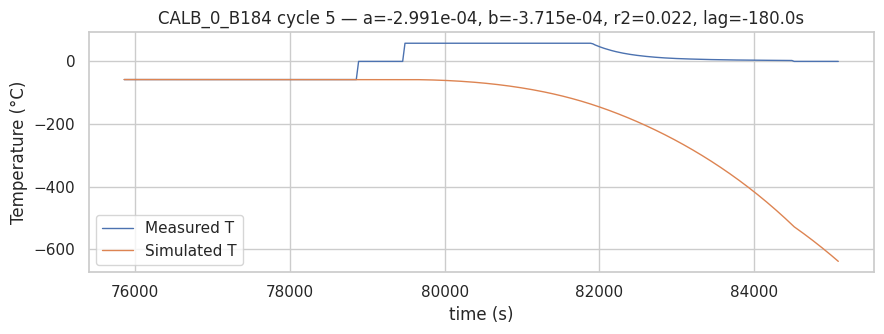


Processing CALB_0_B190 / cycle 37 ...


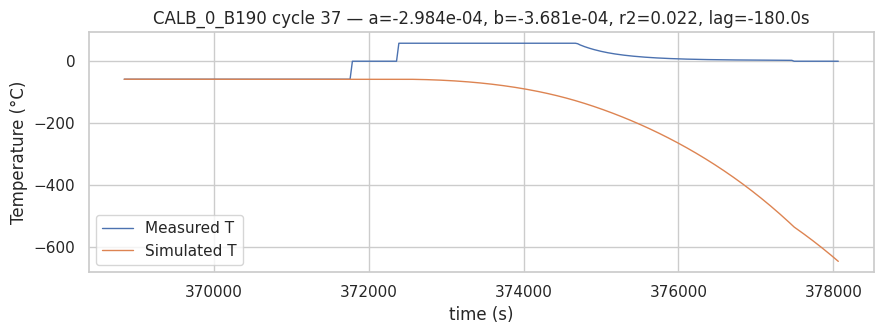


Processing CALB_0_B183 / cycle 2 ...


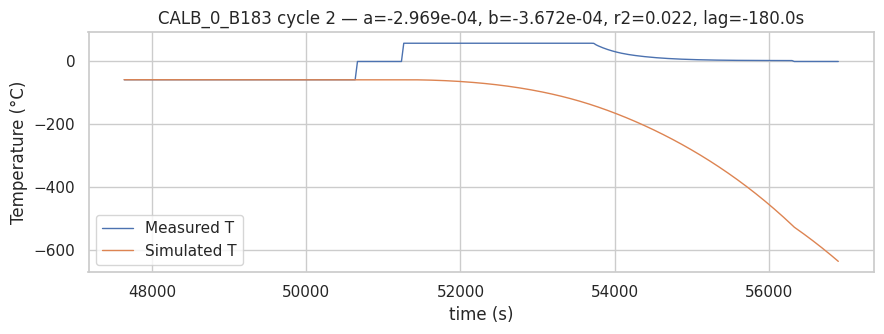


Processing CALB_0_B182 / cycle 40 ...


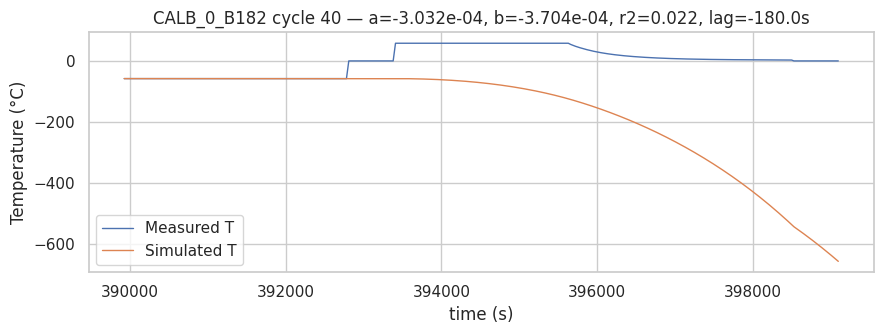


Processing CALB_0_B183 / cycle 20 ...


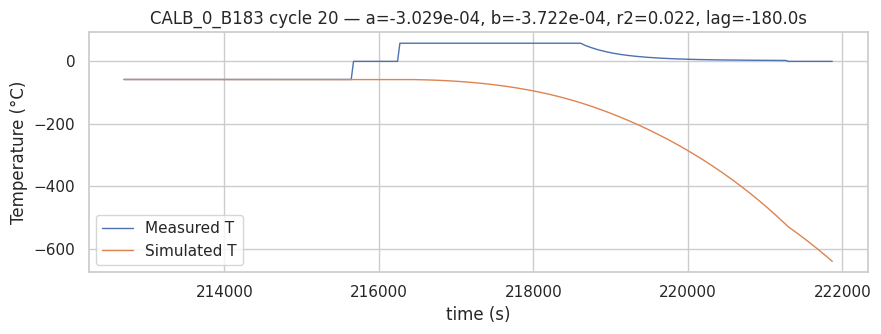


Processing CALB_0_B188 / cycle 23 ...


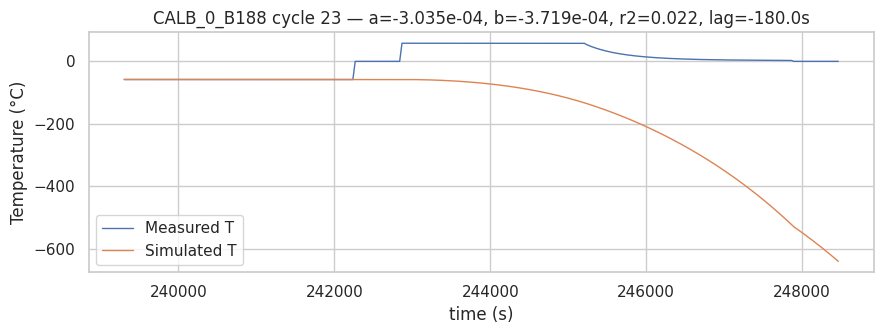


Saved thermal params (sample) to: data_processed/thermal/thermal_params_sample.parquet


,cell_id,cycle,dataset,chemistry,a,b,r2,T_amb,xcorr_lag_s,xcorr_val,n_samples
0,CALB_0_B184,5,CALB,Unknown,-0.000299,-0.000371,0.022403,-58.04811,-180.0,669697.351181,310
1,CALB_0_B190,37,CALB,Unknown,-0.000298,-0.000368,0.021858,-58.02951,-180.0,634185.898305,310
2,CALB_0_B183,2,CALB,Unknown,-0.000297,-0.000367,0.022303,-58.04191,-180.0,662514.843378,310
3,CALB_0_B182,40,CALB,Unknown,-0.000303,-0.000370,0.021758,-58.01711,-180.0,609537.342690,308
4,CALB_0_B183,20,CALB,Unknown,-0.000303,-0.000372,0.022264,-58.02951,-180.0,643522.502981,308
5,CALB_0_B188,23,CALB,Unknown,-0.000304,-0.000372,0.022253,-58.05432,-180.0,637290.399268,307


In [25]:
# Run time-series fits for a small sample of cycles
SAMPLE_COUNT = 6   # number of cycles to fit (tune for runtime)
MAX_LAG_SECONDS = 200  # limit lag search to +/- seconds

# choose top SAMPLE_COUNT cycles by energy_sum with available temperature data
cand = features_df.dropna(subset=['energy_sum','temp_mean']).sort_values('energy_sum', ascending=False)
cand = cand[cand['temp_mean'].notna()]
cand = cand.head(200)  # restrict to top 200 then sample
if len(cand) == 0:
    raise RuntimeError("No candidate cycles with energy/temp — ensure features_df has temp values.")

sample_rows = cand.sample(min(SAMPLE_COUNT, len(cand)), random_state=1).reset_index(drop=True)
print("Selected cycles for time-series thermal fitting:")
display(sample_rows[['cell_id','cycle','dataset','chemistry','energy_sum','temp_mean']])

thermal_results = []
for idx, row in sample_rows.iterrows():
    cell = row['cell_id']; cyc = int(row['cycle'])
    print(f"\nProcessing {cell} / cycle {cyc} ...")
    # load group raw time-series (pyarrow preferred)
    try:
        if USING_PYARROW:
            dataset = ds.dataset(str(PARQUET_FP), format="parquet")
            expr = (ds.field('cell_id') == cell) & (ds.field('cycle') == cyc)
            gtable = dataset.to_table(filter=expr).to_pandas()
        else:
            tmp = pd.read_parquet(PARQUET_FP, columns=['cell_id','cycle','time','voltage','current','temperature'])
            gtable = tmp[(tmp['cell_id']==cell) & (tmp['cycle']==cyc)].sort_values('time')
    except Exception as e:
        print("  failed to load raw group:", e)
        continue

    if gtable.empty:
        print("  empty raw group; skipping")
        continue
    # ensure column names
    if 'temperature' not in gtable.columns or 'voltage' not in gtable.columns or 'current' not in gtable.columns:
        print("  missing columns; skipping")
        continue

    # sanitize and run fit
    t_arr = gtable['time'].to_numpy(dtype=float)
    V_arr = gtable['voltage'].to_numpy(dtype=float)
    I_arr = gtable['current'].to_numpy(dtype=float)
    T_arr = gtable['temperature'].to_numpy(dtype=float)

    fit = fit_single_node_thermal(t_arr, V_arr, I_arr, T_arr, min_points=MIN_POINTS_FOR_RC)
    if not fit.get('success'):
        print("  fit failed:", fit.get('reason'))
        # still compute simple cross-corr if possible
        lag_s, corr_val = xcorr_lag_seconds(V_arr*I_arr, T_arr, t_arr, max_lag_seconds=MAX_LAG_SECONDS)
        thermal_results.append({'cell_id':cell,'cycle':cyc,'dataset':row['dataset'],'chemistry':row['chemistry'],
                                'a':np.nan,'b':np.nan,'r2':np.nan,'xcorr_lag_s':lag_s,'xcorr_val':corr_val,'n_samples':len(t_arr)})
        continue

    # cross-correlation lag
    lag_s, corr_val = xcorr_lag_seconds(fit['P'], fit['T'], fit['t'], max_lag_seconds=MAX_LAG_SECONDS)
    # store results
    thermal_results.append({
        'cell_id': cell, 'cycle': cyc, 'dataset': row['dataset'], 'chemistry': row['chemistry'],
        'a': fit['a'], 'b': fit['b'], 'r2': fit['r2'], 'T_amb': fit['T_amb'],
        'xcorr_lag_s': lag_s, 'xcorr_val': corr_val, 'n_samples': len(fit['t'])
    })

    # quick plot of measured vs simulated T for this cycle
    plt.figure(figsize=(9,3.5))
    plt.plot(fit['t'], fit['T'], label='Measured T', linewidth=1)
    plt.plot(fit['t'], fit['Tsim'], label='Simulated T', linewidth=1)
    plt.xlabel('time (s)'); plt.ylabel('Temperature (°C)')
    plt.title(f"{cell} cycle {cyc} — a={fit['a']:.3e}, b={fit['b']:.3e}, r2={fit['r2']:.3f}, lag={lag_s:.1f}s")
    plt.legend(); plt.tight_layout()
    plt.savefig(THERM_DIR / f"thermal_fit_{cell}_{cyc}.png", dpi=300)
    plt.show()

# save thermal results
thermal_df = pd.DataFrame(thermal_results)
thermal_df.to_parquet(THERM_DIR / "thermal_params_sample.parquet", index=False)
thermal_df.to_csv(THERM_DIR / "thermal_params_sample.csv", index=False)
print("\nSaved thermal params (sample) to:", THERM_DIR / "thermal_params_sample.parquet")
display(thermal_df)

**Statistical model: energy - temperature rise (fast, across all cycles)**

To scale beyond the small time-series sample we used cycle-level features: regress `temp_rise` against `energy_sum` and `power_mean` per chemistry to get a fast thermal proxy (useful when raw time-series is too big).

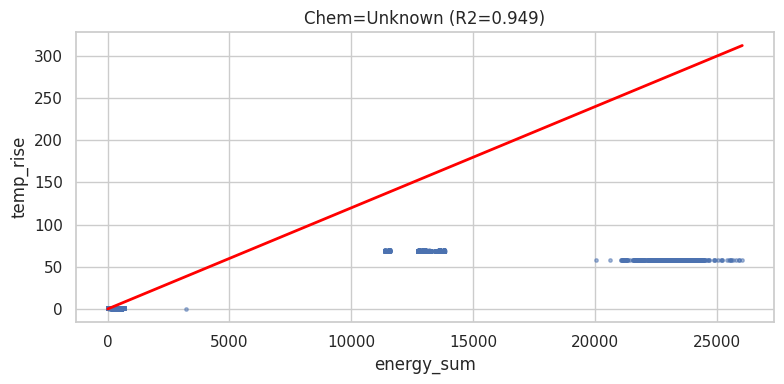

Saved per-chemistry regression summary: data_processed/thermal/cyclelevel_thermal_regression_by_chemistry.csv


,chemistry,coef_energy,coef_power,intercept,r2,n
0,Unknown,0.011983,-2.810775,0.107093,0.949058,18400


In [26]:
# Cycle-level regression 
from sklearn.metrics import r2_score

reg_results = []
for chem in (features_df['chemistry'].fillna('unknown').unique()):
    sub = features_df[features_df['chemistry']==chem].dropna(subset=['energy_sum','temp_rise'])
    if len(sub) < 20:
        continue
    X = sub[['energy_sum','power_mean']].fillna(0.0).values
    y = sub['temp_rise'].values
    lr = LinearRegression().fit(X, y)
    ypred = lr.predict(X)
    r2 = r2_score(y, ypred)
    reg_results.append({'chemistry':chem,'coef_energy':float(lr.coef_[0]), 'coef_power':float(lr.coef_[1]),
                        'intercept':float(lr.intercept_), 'r2':float(r2), 'n':len(sub)})
    # save and plot scatter for major chemistry
    if len(sub) > 200:
        plt.figure(figsize=(8,4))
        plt.scatter(sub['energy_sum'], sub['temp_rise'], s=6, alpha=0.5)
        # regression wrt energy only (for visualization)
        xs = np.linspace(sub['energy_sum'].min(), sub['energy_sum'].max(), 80).reshape(-1,1)
        ys = lr.coef_[0] * xs + lr.intercept_  # keep power mean fixed near 0
        plt.plot(xs, ys, color='red', linewidth=2)
        plt.xlabel('energy_sum'); plt.ylabel('temp_rise')
        plt.title(f'Chem={chem} (R2={r2:.3f})')
        plt.tight_layout()
        plt.savefig(FIGS / f"energy_temp_rise_reg_{chem}.png", dpi=300)
        plt.show()

reg_df = pd.DataFrame(reg_results)
reg_df.to_csv(THERM_DIR / "cyclelevel_thermal_regression_by_chemistry.csv", index=False)
print("Saved per-chemistry regression summary:", THERM_DIR / "cyclelevel_thermal_regression_by_chemistry.csv")
display(reg_df)

** Week 3 and 4 Conclusion**

Files created:
- `data_processed/thermal/thermal_params_sample.parquet` — time-series fit results for sampled cycles.
- `data_processed/thermal/cyclelevel_thermal_regression_by_chemistry.csv` — cycle-level regression coefficients.
- Figures in `data_processed/figures/` and `data_processed/thermal/`.

How to interpret:
- `a` (heating gain) units: °C per (W) larger `a` → same power produces larger temperature rate change.
- `b` (cooling) units: s⁻¹ — larger `b` → faster cooling to ambient.
- `xcorr_lag_s` positive → power leads temperature by that many seconds (typical thermal response delays).
- If cycle-level regressions show high R² for a chemistry, simple energy-based predictors may suffice for that chemistry.